In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('ncr_ride_bookings.csv')
df

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,2024-11-11,19:34:01,"""CNR6500631""",Completed,"""CID4337371""",Go Mini,MG Road,Ghitorni,10.2,44.4,...,NaN,NaN,NaN,NaN,NaN,475.0,40.08,3.7,4.1,Uber Wallet
149996,2024-11-24,15:55:09,"""CNR2468611""",Completed,"""CID2325623""",Go Mini,Golf Course Road,Akshardham,5.1,30.8,...,NaN,NaN,NaN,NaN,NaN,1093.0,21.31,4.8,5.0,UPI
149997,2024-09-18,10:55:15,"""CNR6358306""",Completed,"""CID9925486""",Go Sedan,Satguru Ram Singh Marg,Jor Bagh,2.7,23.4,...,NaN,NaN,NaN,NaN,NaN,852.0,15.93,3.9,4.4,Cash
149998,2024-10-05,07:53:34,"""CNR3030099""",Completed,"""CID9415487""",Auto,Ghaziabad,Saidulajab,6.9,39.6,...,NaN,NaN,NaN,NaN,NaN,333.0,45.54,4.1,3.7,UPI


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  str    
 1   Time                               150000 non-null  str    
 2   Booking ID                         150000 non-null  str    
 3   Booking Status                     150000 non-null  str    
 4   Customer ID                        150000 non-null  str    
 5   Vehicle Type                       150000 non-null  str    
 6   Pickup Location                    150000 non-null  str    
 7   Drop Location                      150000 non-null  str    
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  10500 non-null 

In [4]:
## Date and time have wrong data type 
df['Date'] = pd.to_datetime(df['Date'])
df['Time'] = pd.to_datetime(df['Time'],format='%H:%M:%S').dt.time

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   Date                               150000 non-null  datetime64[us]
 1   Time                               150000 non-null  object        
 2   Booking ID                         150000 non-null  str           
 3   Booking Status                     150000 non-null  str           
 4   Customer ID                        150000 non-null  str           
 5   Vehicle Type                       150000 non-null  str           
 6   Pickup Location                    150000 non-null  str           
 7   Drop Location                      150000 non-null  str           
 8   Avg VTAT                           139500 non-null  float64       
 9   Avg CTAT                           102000 non-null  float64       
 10  Cancelled Rides by Customer    

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df['Booking ID'].nunique()

148767

In [8]:
df['Booking ID'].value_counts().head(20)

Booking ID
"CNR7908610"    3
"CNR9603232"    3
"CNR3648267"    3
"CNR2726142"    3
"CNR7199036"    3
"CNR7585544"    3
"CNR7642097"    3
"CNR5292943"    3
"CNR6337479"    3
"CNR2687237"    2
"CNR5380412"    2
"CNR5071968"    2
"CNR2290384"    2
"CNR3466923"    2
"CNR5743864"    2
"CNR6919794"    2
"CNR7417664"    2
"CNR1197334"    2
"CNR3011900"    2
"CNR6977914"    2
Name: count, dtype: int64

In [9]:
(df['Booking ID'].value_counts() > 1).sum()

np.int64(1224)

In [10]:
repr(df['Booking ID'].iloc[0])

'\'"CNR5884300"\''

In [11]:
df['Booking ID'] = df['Booking ID'].str.strip("'\"")

In [12]:
df[df['Booking ID'] == "CNR7908610"]


,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
2390,2024-03-26,15:54:11,CNR7908610,Completed,"""CID7755899""",Uber XL,Satguru Ram Singh Marg,Bahadurgarh,9.0,22.7,...,NaN,NaN,NaN,NaN,NaN,707.0,34.64,3.8,4.8,Cash
105065,2024-09-03,19:38:29,CNR7908610,Completed,"""CID5251969""",Go Mini,Saket A Block,Keshav Puram,13.3,36.0,...,NaN,NaN,NaN,NaN,NaN,456.0,27.73,4.6,4.7,Cash
130690,2024-12-30,07:01:22,CNR7908610,Completed,"""CID3266637""",Bike,Bhikaji Cama Place,Mandi House,7.5,38.3,...,NaN,NaN,NaN,NaN,NaN,495.0,27.70,4.8,3.9,UPI


In [13]:
##Missing value analysis
missing_values = df.isnull().sum()
print(missing_values.sort_values(ascending=False))


Incomplete Rides Reason              141000
Incomplete Rides                     141000
Reason for cancelling by Customer    139500
Cancelled Rides by Customer          139500
Cancelled Rides by Driver            123000
Driver Cancellation Reason           123000
Driver Ratings                        57000
Customer Rating                       57000
Avg CTAT                              48000
Ride Distance                         48000
Booking Value                         48000
Payment Method                        48000
Avg VTAT                              10500
Customer ID                               0
Booking Status                            0
Booking ID                                0
Time                                      0
Date                                      0
Pickup Location                           0
Drop Location                             0
Vehicle Type                              0
dtype: int64


In [14]:
missing_values_percent = df.isnull().sum()/len(df) *100
print(missing_values_percent.sort_values(ascending = False))

Incomplete Rides Reason              94.0
Incomplete Rides                     94.0
Reason for cancelling by Customer    93.0
Cancelled Rides by Customer          93.0
Cancelled Rides by Driver            82.0
Driver Cancellation Reason           82.0
Driver Ratings                       38.0
Customer Rating                      38.0
Avg CTAT                             32.0
Ride Distance                        32.0
Booking Value                        32.0
Payment Method                       32.0
Avg VTAT                              7.0
Customer ID                           0.0
Booking Status                        0.0
Booking ID                            0.0
Time                                  0.0
Date                                  0.0
Pickup Location                       0.0
Drop Location                         0.0
Vehicle Type                          0.0
dtype: float64


In [15]:
df[df['Booking Value'].isnull()].head(20)


,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,CNR5884300,No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2024-09-14,12:49:09,CNR4510807,No Driver Found,"""CID7873618""",Go Sedan,Noida Sector 62,Noida Sector 18,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11,2024-09-18,08:09:38,CNR9551927,No Driver Found,"""CID7568143""",Auto,Vidhan Sabha,AIIMS,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12,2024-06-25,22:44:15,CNR4386945,Cancelled by Driver,"""CID5543520""",eBike,Patel Chowk,Kherki Daula Toll,4.6,NaN,...,NaN,1.0,Personal & Car related issues,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17,2024-12-15,15:08:25,CNR6739317,Cancelled by Driver,"""CID8682675""",Go Sedan,Vinobapuri,GTB Nagar,6.0,NaN,...,NaN,1.0,Customer related issue,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18,2024-11-24,09:07:10,CNR6126048,Cancelled by Customer,"""CID1060329""",eBike,Kashmere Gate,Anand Vihar,12.4,NaN,...,Driver is not moving towards pickup location,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19,2024-05-24,19:53:57,CNR9465840,Cancelled by Driver,"""CID9046501""",eBike,Pitampura,Rajiv Nagar,10.3,NaN,...,NaN,1.0,Customer related issue,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26,2024-01-26,09:44:00,CNR3614535,Cancelled by Driver,"""CID2507102""",Auto,Cyber Hub,Saket,11.5,NaN,...,NaN,1.0,Personal & Car related issues,NaN,NaN,NaN,NaN,NaN,NaN,NaN
27,2024-04-12,19:42:35,CNR4499383,No Driver Found,"""CID5717521""",Premier Sedan,Sadar Bazar Gurgaon,Mehrauli,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
30,2024-05-18,17:37:52,CNR2178654,Cancelled by Driver,"""CID3631860""",Go Mini,Qutub Minar,Vishwavidyalaya,9.2,NaN,...,NaN,1.0,More than permitted people in there,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
df[df['Booking Value'].isnull()][['Booking Status','Booking Value']].head(20)

,Booking Status,Booking Value
0,No Driver Found,NaN
8,No Driver Found,NaN
11,No Driver Found,NaN
12,Cancelled by Driver,NaN
17,Cancelled by Driver,NaN
18,Cancelled by Customer,NaN
19,Cancelled by Driver,NaN
26,Cancelled by Driver,NaN
27,No Driver Found,NaN
30,Cancelled by Driver,NaN


In [17]:
pd.crosstab(
    df['Booking Status'],
    df['Booking Value'].isnull()
)

Booking Value,False,True
Booking Status,,
Cancelled by Customer,0,10500
Cancelled by Driver,0,27000
Completed,93000,0
Incomplete,9000,0
No Driver Found,0,10500


In [18]:
df['Booking Status'].unique()

<ArrowStringArray>
[      'No Driver Found',            'Incomplete',             'Completed',
   'Cancelled by Driver', 'Cancelled by Customer']
Length: 5, dtype: str

In [19]:
df[df['Booking Status'] == 'Completed'].head(50)

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
2,2024-08-23,08:56:10,CNR8494506,Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,CNR8906825,Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,CNR1950162,Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI
5,2024-02-06,09:44:56,CNR4096693,Completed,"""CID4670564""",Auto,AIIMS,Narsinghpur,5.1,18.1,...,NaN,NaN,NaN,NaN,NaN,316.0,4.85,4.1,4.6,UPI
6,2024-06-17,15:45:58,CNR2002539,Completed,"""CID6800553""",Go Mini,Vaishali,Punjabi Bagh,7.1,20.4,...,NaN,NaN,NaN,NaN,NaN,640.0,41.24,4.0,4.1,UPI
7,2024-03-19,17:37:37,CNR6568000,Completed,"""CID8610436""",Auto,Mayur Vihar,Cyber Hub,12.1,16.5,...,NaN,NaN,NaN,NaN,NaN,136.0,6.56,4.4,4.2,UPI
10,2024-06-14,16:24:12,CNR9070334,Completed,"""CID6680340""",Auto,Udyog Bhawan,Dwarka Sector 21,7.7,18.9,...,NaN,NaN,NaN,NaN,NaN,181.0,19.84,4.2,4.9,Cash
13,2024-09-11,19:29:39,CNR2987763,Completed,"""CID2669710""",Go Mini,Malviya Nagar,Ghitorni Village,12.2,28.2,...,NaN,NaN,NaN,NaN,NaN,394.0,21.44,4.1,4.7,UPI
14,2024-10-18,18:28:53,CNR8962232,Completed,"""CID1789354""",Go Mini,Madipur,GTB Nagar,14.0,30.9,...,NaN,NaN,NaN,NaN,NaN,836.0,39.55,4.7,4.4,UPI
15,2024-06-07,15:05:35,CNR2390352,Completed,"""CID5432215""",Auto,Jama Masjid,Khan Market,8.5,36.9,...,NaN,NaN,NaN,NaN,NaN,410.0,34.76,4.0,4.9,Uber Wallet


In [20]:
df[df['Booking Value'].isnull()].isnull().sum()

Date                                     0
Time                                     0
Booking ID                               0
Booking Status                           0
Customer ID                              0
Vehicle Type                             0
Pickup Location                          0
Drop Location                            0
Avg VTAT                             10500
Avg CTAT                             48000
Cancelled Rides by Customer          37500
Reason for cancelling by Customer    37500
Cancelled Rides by Driver            21000
Driver Cancellation Reason           21000
Incomplete Rides                     48000
Incomplete Rides Reason              48000
Booking Value                        48000
Ride Distance                        48000
Driver Ratings                       48000
Customer Rating                      48000
Payment Method                       48000
dtype: int64

In [21]:
df.describe()

,Date,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Cancelled Rides by Driver,Incomplete Rides,Booking Value,Ride Distance,Driver Ratings,Customer Rating
count,150000,139500.000000,102000.000000,10500.0,27000.0,9000.0,102000.000000,102000.000000,93000.000000,93000.000000
mean,2024-06-30 16:42:40.320000,8.456352,29.149636,1.0,1.0,1.0,508.295912,24.637012,4.230992,4.404584
min,2024-01-01 00:00:00,2.000000,10.000000,1.0,1.0,1.0,50.000000,1.000000,3.000000,3.000000
25%,2024-03-31 00:00:00,5.300000,21.600000,1.0,1.0,1.0,234.000000,12.460000,4.100000,4.200000
50%,2024-07-01 00:00:00,8.300000,28.800000,1.0,1.0,1.0,414.000000,23.720000,4.300000,4.500000
75%,2024-09-30 00:00:00,11.300000,36.800000,1.0,1.0,1.0,689.000000,36.820000,4.600000,4.800000
max,2024-12-30 00:00:00,20.000000,45.000000,1.0,1.0,1.0,4277.000000,50.000000,5.000000,5.000000
std,NaN,3.773564,8.902577,0.0,0.0,0.0,395.805774,14.002138,0.436871,0.437819


In [22]:
#Checking for typos
df['Booking Status'].value_counts()
df['Vehicle Type'].value_counts()

Vehicle Type
Auto             37419
Go Mini          29806
Go Sedan         27141
Bike             22517
Premier Sedan    18111
eBike            10557
Uber XL           4449
Name: count, dtype: int64

Temporal Feature Extraction

In [23]:
print(df['Date'].dtype)
print(df['Time'].dtype)

datetime64[us]
object


In [24]:
print(type(df['Date']))
print(type(df['Time']))

<class 'pandas.Series'>
<class 'pandas.Series'>


In [25]:
df['Time'].apply(type).value_counts()

Time
<class 'datetime.time'>    150000
Name: count, dtype: int64

In [26]:
df['DateTime'] = pd.to_datetime(
    df['Date'].astype(str) + ' ' + df['Time'].astype(str)
)

In [27]:
df


,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,DateTime
0,2024-03-23,12:29:38,CNR5884300,No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-03-23 12:29:38
1,2024-11-29,18:01:39,CNR1326809,Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI,2024-11-29 18:01:39
2,2024-08-23,08:56:10,CNR8494506,Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card,2024-08-23 08:56:10
3,2024-10-21,17:17:25,CNR8906825,Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI,2024-10-21 17:17:25
4,2024-09-16,22:08:00,CNR1950162,Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI,2024-09-16 22:08:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,2024-11-11,19:34:01,CNR6500631,Completed,"""CID4337371""",Go Mini,MG Road,Ghitorni,10.2,44.4,...,NaN,NaN,NaN,NaN,475.0,40.08,3.7,4.1,Uber Wallet,2024-11-11 19:34:01
149996,2024-11-24,15:55:09,CNR2468611,Completed,"""CID2325623""",Go Mini,Golf Course Road,Akshardham,5.1,30.8,...,NaN,NaN,NaN,NaN,1093.0,21.31,4.8,5.0,UPI,2024-11-24 15:55:09
149997,2024-09-18,10:55:15,CNR6358306,Completed,"""CID9925486""",Go Sedan,Satguru Ram Singh Marg,Jor Bagh,2.7,23.4,...,NaN,NaN,NaN,NaN,852.0,15.93,3.9,4.4,Cash,2024-09-18 10:55:15
149998,2024-10-05,07:53:34,CNR3030099,Completed,"""CID9415487""",Auto,Ghaziabad,Saidulajab,6.9,39.6,...,NaN,NaN,NaN,NaN,333.0,45.54,4.1,3.7,UPI,2024-10-05 07:53:34


In [28]:
type(df['DateTime'])

pandas.Series

In [29]:
df['Month'] = df['Date'].dt.month_name()
df['Hour'] = df['DateTime'].dt.hour
df['Day'] = df['DateTime'].dt.day_name()
df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,DateTime,Month,Hour,Day
0,2024-03-23,12:29:38,CNR5884300,No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2024-03-23 12:29:38,March,12,Saturday
1,2024-11-29,18:01:39,CNR1326809,Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI,2024-11-29 18:01:39,November,18,Friday
2,2024-08-23,08:56:10,CNR8494506,Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,627.0,13.58,4.9,4.9,Debit Card,2024-08-23 08:56:10,August,8,Friday
3,2024-10-21,17:17:25,CNR8906825,Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,416.0,34.02,4.6,5.0,UPI,2024-10-21 17:17:25,October,17,Monday
4,2024-09-16,22:08:00,CNR1950162,Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,737.0,48.21,4.1,4.3,UPI,2024-09-16 22:08:00,September,22,Monday


In [30]:
##Creating weekend flag
df['weekend_flag'] = df['Day'].isin(['Saturday','Sunday'])


In [31]:
##Creating time wise categories
def time_categorization(Hour):
    if Hour >=5 and Hour < 12:
        return 'Morning'
    elif Hour >=12 and Hour < 17:
        return 'Afternoon'
    elif Hour >=17 and Hour < 21:
        return 'Evening'
    else:
        return 'Night'
df['time_category'] = df['Hour'].apply(time_categorization)
        

In [32]:
df['Booking Status'].value_counts()

Booking Status
Completed                93000
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Incomplete                9000
Name: count, dtype: int64

<Figure size 800x500 with 0 Axes>

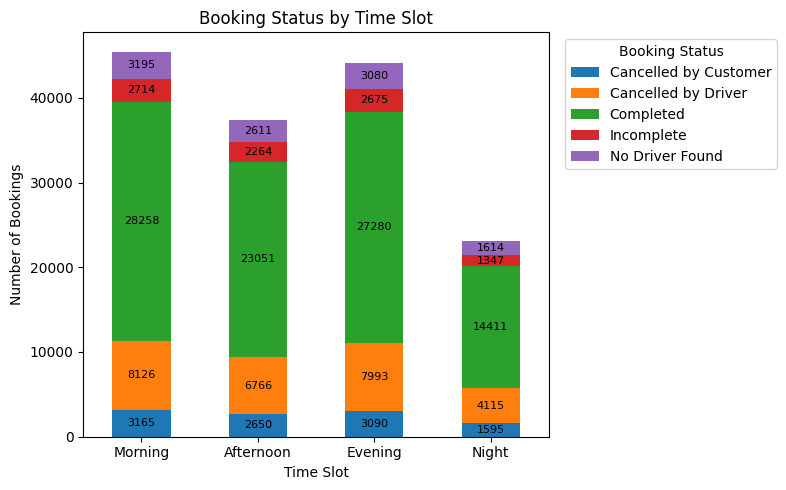

In [36]:
#Time slot wise booking status
df.groupby('time_category')['Booking Status'].value_counts().sort_values(ascending = False).reset_index()

# Booking Status by Time Slot

times = ['Morning', 'Afternoon', 'Evening', 'Night']

df['time_category'] = pd.Categorical(
    df['time_category'],
    categories=times,
    ordered=True
)

status_time = (
    df.groupby(['time_category', 'Booking Status'])
      .size()
      .unstack(fill_value=0)
)

plt.figure(figsize=(8,5))

ax = status_time.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.title("Booking Status by Time Slot")
plt.xlabel("Time Slot")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=0)

plt.legend(
    title="Booking Status",
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

# Optional: add values inside each stack
for container in ax.containers:
    ax.bar_label(
        container,
        label_type='center',
        fontsize=8
    )

plt.tight_layout()
plt.show()

In [35]:
df.info()

df = df.drop(['Date','Time'], axis = 1)

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 27 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   Date                               150000 non-null  datetime64[us]
 1   Time                               150000 non-null  object        
 2   Booking ID                         150000 non-null  str           
 3   Booking Status                     150000 non-null  str           
 4   Customer ID                        150000 non-null  str           
 5   Vehicle Type                       150000 non-null  str           
 6   Pickup Location                    150000 non-null  str           
 7   Drop Location                      150000 non-null  str           
 8   Avg VTAT                           139500 non-null  float64       
 9   Avg CTAT                           102000 non-null  float64       
 10  Cancelled Rides by Customer    

In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   Booking ID                         150000 non-null  str           
 1   Booking Status                     150000 non-null  str           
 2   Customer ID                        150000 non-null  str           
 3   Vehicle Type                       150000 non-null  str           
 4   Pickup Location                    150000 non-null  str           
 5   Drop Location                      150000 non-null  str           
 6   Avg VTAT                           139500 non-null  float64       
 7   Avg CTAT                           102000 non-null  float64       
 8   Cancelled Rides by Customer        10500 non-null   float64       
 9   Reason for cancelling by Customer  10500 non-null   str           
 10  Cancelled Rides by Driver      

In [37]:
df.to_csv('Uber_Processed.csv', index=False)

In [38]:
## KPI's
import math
total_bookings = len(df)
completed_rides = (df['Booking Status'] == 'Completed').sum()
cancelled_rides = df['Booking Status'].isin(['Cancelled by Driver', 'Cancelled by Customer']).sum()
completion_rate = (df['Booking Status'] == 'Completed').sum()/len(df) *100
cancelled_rate = cancelled_rides/ total_bookings * 100 


rides_completed = df[df['Booking Status'] == 'Completed']

total_revenue = rides_completed['Booking Value'].sum()
avg_fare = rides_completed['Booking Value'].mean()
avg_dist = rides_completed['Ride Distance'].mean()
avg_driver_rating = df['Driver Ratings'].mean()
avg_cust_rating = df['Customer Rating'].mean()
unq_customers = df['Customer ID'].nunique()
avg_wait_time = rides_completed['Avg VTAT'].mean()
avg_trip_duration = rides_completed['Avg CTAT'].mean()

print(f"Total Bookings  {total_bookings}")
print(f"Completed Bookings  {completed_rides}")
print(f"Cancelled Bookings  {cancelled_rides}")
print(f"Completion Rate  {completion_rate} %")
print(f"Cancellation Rate  {cancelled_rate} %")
print(f"Total Revenue   Rs {total_revenue}")
print(f"Average Fare  {round(avg_fare,2)}")
print(f"Average Distance  {round(avg_dist,2)}")
print(f"Average Driver Rating  {round(avg_driver_rating,2)}")
print(f"Average Customer Rating  {round(avg_cust_rating,2)}")
print(f"Unique Customers  {unq_customers}")
print(f"Average Wait time  {round(avg_wait_time,1)} min")
print(f"Average Trip Duration  {math.floor(avg_trip_duration)} Km")


Total Bookings  150000
Completed Bookings  93000
Cancelled Bookings  37500
Completion Rate  62.0 %
Cancellation Rate  25.0 %
Total Revenue   Rs 47260574.0
Average Fare  508.18
Average Distance  26.0
Average Driver Rating  4.23
Average Customer Rating  4.4
Unique Customers  148788
Average Wait time  8.5 min
Average Trip Duration  30 Km


In [39]:
##Booking status 
df["Booking Status"].value_counts()

Booking Status
Completed                93000
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Incomplete                9000
Name: count, dtype: int64

In [40]:
#Booking status %age
avg = df["Booking Status"].value_counts()/len(df) *100
avg

Booking Status
Completed                62.0
Cancelled by Driver      18.0
No Driver Found           7.0
Cancelled by Customer     7.0
Incomplete                6.0
Name: count, dtype: float64

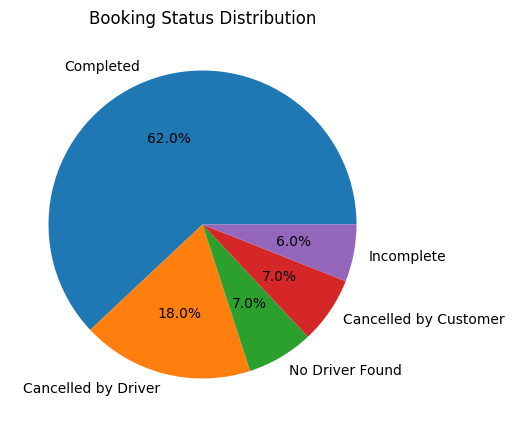

In [41]:
#Pie chart for Booking Status
plt.figure(figsize=(8,5))
plt.pie(
    avg,
    labels = avg.index,
    autopct='%1.1f%%'
)
plt.title('Booking Status Distribution')
plt.show()

In [42]:
completed = df[df['Booking Status'] == 'Completed'].copy()

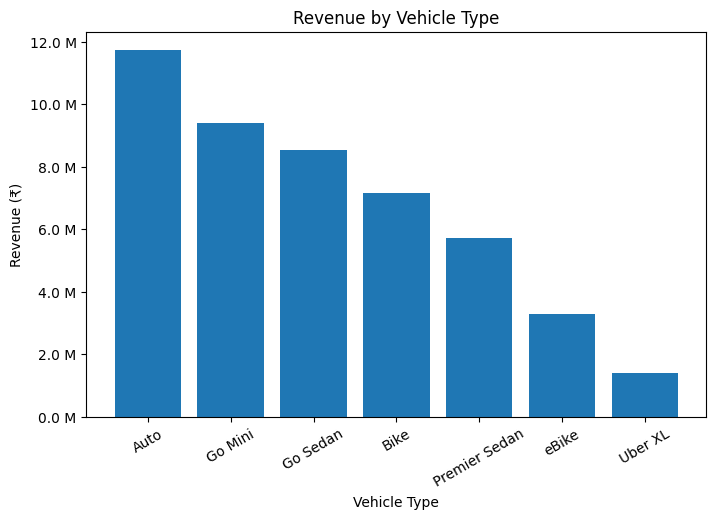

In [43]:
#Revenue by Vehicle type
from matplotlib.ticker import FuncFormatter
revenue_vehicle = (
    completed.groupby('Vehicle Type')['Booking Value']
    .sum()
    .sort_values(ascending=False).reset_index()
)

plt.figure(figsize=(8,5))

plt.bar(revenue_vehicle['Vehicle Type'], revenue_vehicle['Booking Value'])

plt.title('Revenue by Vehicle Type')
plt.xlabel('Vehicle Type')
plt.ylabel('Revenue (₹)')
plt.xticks(rotation=30)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{x/1_000_000:.1f} M')
)
plt.show()

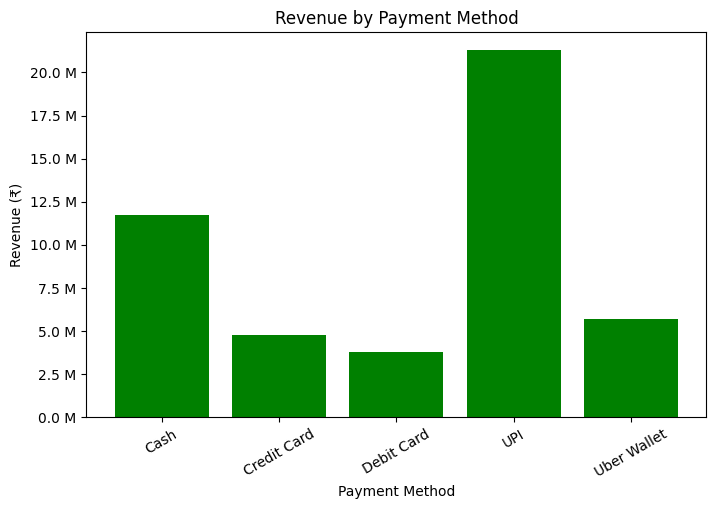

In [44]:
#Revenue by Payment Method
rev_pay_method = completed.groupby('Payment Method')['Booking Value'].sum().reset_index()

plt.figure(figsize=(8,5))

plt.bar(rev_pay_method['Payment Method'], rev_pay_method['Booking Value'], color = 'green')

plt.title('Revenue by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Revenue (₹)')
plt.xticks(rotation=30)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{x/1_000_000:.1f} M')
)
plt.show()

In [45]:
#Month wise revenue
months = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

completed['Month'] = pd.Categorical(
    completed['Month'],
    categories=months,
    ordered=True
)

In [46]:

rev_monthly = completed.groupby('Month')['Booking Value'].sum().reset_index()
rev_monthly

,Month,Booking Value
0,January,4001547.0
1,February,3756610.0
2,March,4174900.0
3,April,3885255.0
4,May,3935207.0
5,June,3964298.0
6,July,3961939.0
7,August,3867753.0
8,September,3820536.0
9,October,4008403.0


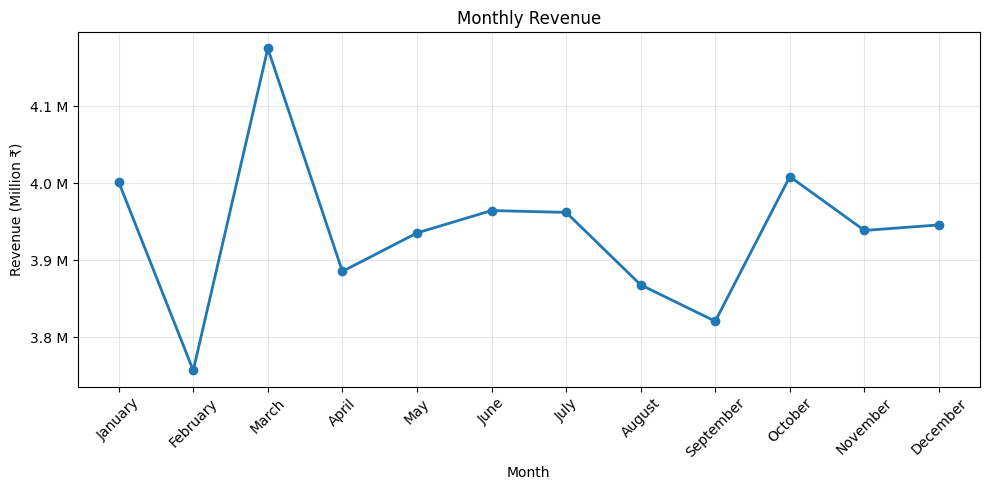

In [47]:
plt.figure(figsize=(10,5))

plt.plot(
    rev_monthly['Month'],
    rev_monthly['Booking Value'],
    marker='o',
    linewidth=2
)

plt.title('Monthly Revenue')
plt.xlabel('Month')
plt.ylabel('Revenue (Million ₹)')

# Show values in millions
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{x/1_000_000:.1f} M')
)

plt.grid(alpha=0.3)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

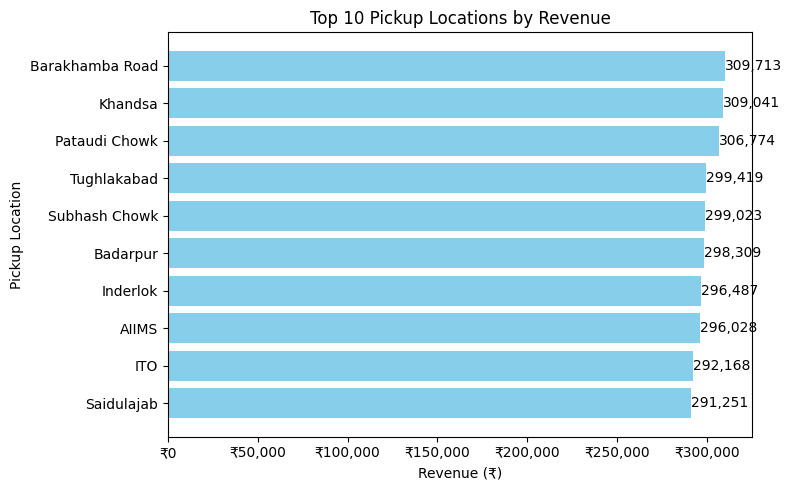

In [48]:
#Revenue from Top 10 pickup Locations
completed['Pickup Location'].unique()
pickup_revenue = completed.groupby('Pickup Location')['Booking Value'].sum().sort_values(ascending = False).head(10).reset_index()
plt.figure(figsize=(8,5))

bars = plt.barh(
    pickup_revenue['Pickup Location'],
    pickup_revenue['Booking Value'],
    color='skyblue'
)
# Show values at the end of each bar
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 20,                    # slightly to the right of the bar
        bar.get_y() + bar.get_height()/2,
        f'{int(width):,}',             # 2,362 format
        va='center',
        fontsize=10
    )
plt.title('Top 10 Pickup Locations by Revenue')
plt.xlabel('Revenue (₹)')
plt.ylabel('Pickup Location')

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'₹{x:,.0f}')
)

# Highest revenue at the top
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

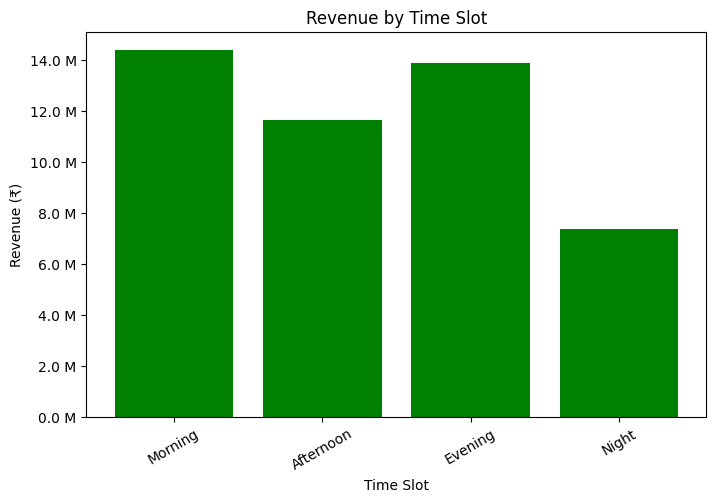

In [49]:
#Revenue by time slot 
times = ['Morning','Afternoon','Evening','Night']
completed['time_category'] = pd.Categorical(completed['time_category'], categories =times,ordered=True)
rev_by_time_slot = completed.groupby('time_category')['Booking Value'].sum().reset_index()

plt.figure(figsize=(8,5))

plt.bar(rev_by_time_slot['time_category'], rev_by_time_slot['Booking Value'], color = 'green')

plt.title('Revenue by Time Slot')
plt.xlabel('Time Slot')
plt.ylabel('Revenue (₹)')
plt.xticks(rotation=30)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{x/1_000_000:.1f} M')
)

plt.show()

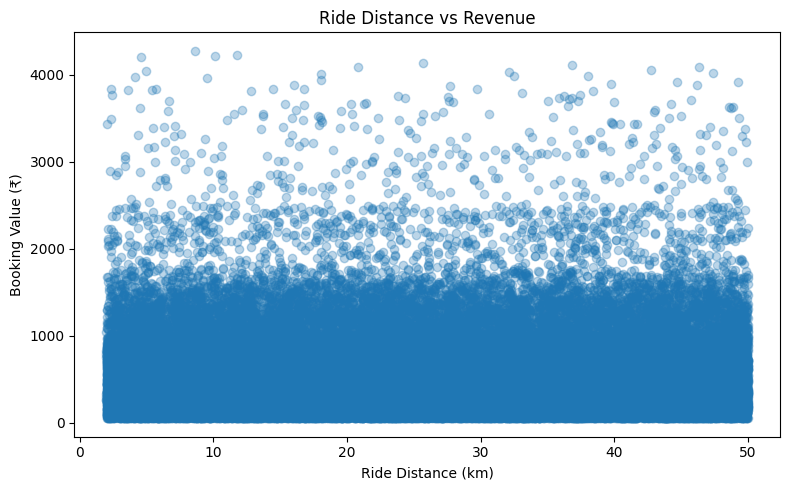

In [50]:
#Revenue by ride distance
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    completed['Ride Distance'],
    completed['Booking Value'],
    alpha=0.3
)

plt.title('Ride Distance vs Revenue')
plt.xlabel('Ride Distance (km)')
plt.ylabel('Booking Value (₹)')

plt.tight_layout()
plt.show()

In [51]:
completed.groupby('Vehicle Type')['Booking Value'].mean()

Vehicle Type
Auto             506.483049
Bike             509.114508
Go Mini          507.381422
Go Sedan         512.026865
Premier Sedan    509.567632
Uber XL          505.302192
eBike            503.458556
Name: Booking Value, dtype: float64

In [52]:
completed.groupby('Vehicle Type')['Ride Distance'].mean()

Vehicle Type
Auto             25.989588
Bike             25.998760
Go Mini          25.989844
Go Sedan         25.977648
Premier Sedan    25.946155
Uber XL          25.723284
eBike            26.342151
Name: Ride Distance, dtype: float64

In [53]:
completed.info()

<class 'pandas.DataFrame'>
Index: 93000 entries, 2 to 149999
Data columns (total 25 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   Booking ID                         93000 non-null  str           
 1   Booking Status                     93000 non-null  str           
 2   Customer ID                        93000 non-null  str           
 3   Vehicle Type                       93000 non-null  str           
 4   Pickup Location                    93000 non-null  str           
 5   Drop Location                      93000 non-null  str           
 6   Avg VTAT                           93000 non-null  float64       
 7   Avg CTAT                           93000 non-null  float64       
 8   Cancelled Rides by Customer        0 non-null      float64       
 9   Reason for cancelling by Customer  0 non-null      str           
 10  Cancelled Rides by Driver          0 non-null    

Rides Analysis

In [54]:
#Number of bookings by vehicle type
df['Vehicle Type'].value_counts()
bookings_vehicle = df.groupby('Vehicle Type').size().sort_values(ascending = False).reset_index(name = 'Bookings')

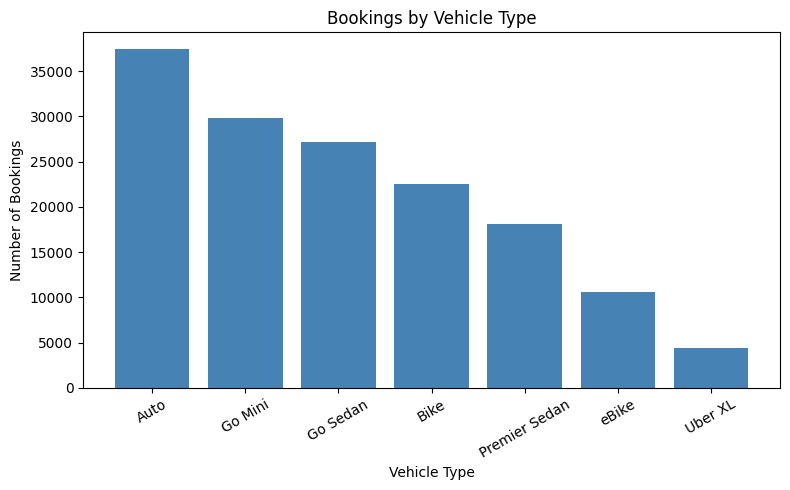

In [55]:
plt.figure(figsize=(8,5))

plt.bar(
    bookings_vehicle['Vehicle Type'],
    bookings_vehicle['Bookings'],
    color='steelblue'
)

plt.title('Bookings by Vehicle Type')
plt.xlabel('Vehicle Type')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

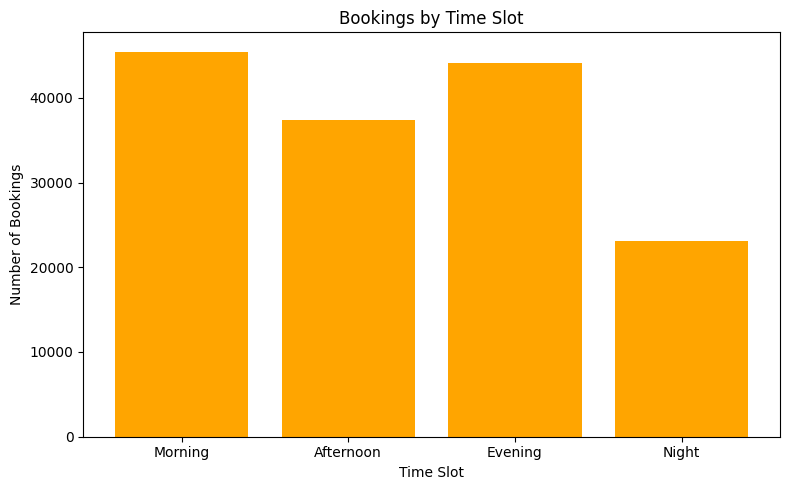

In [56]:
#Bookings by time slot
times = ['Morning', 'Afternoon', 'Evening', 'Night']

df['time_category'] = pd.Categorical(
    df['time_category'],
    categories=times,
    ordered=True
)

bookings_time = (
    df.groupby('time_category', observed=True)
      .size()
      .reset_index(name='Bookings')
)

plt.figure(figsize=(8,5))

plt.bar(
    bookings_time['time_category'],
    bookings_time['Bookings'],
    color='orange'
)


plt.title('Bookings by Time Slot')
plt.xlabel('Time Slot')
plt.ylabel('Number of Bookings')

plt.tight_layout()
plt.show()

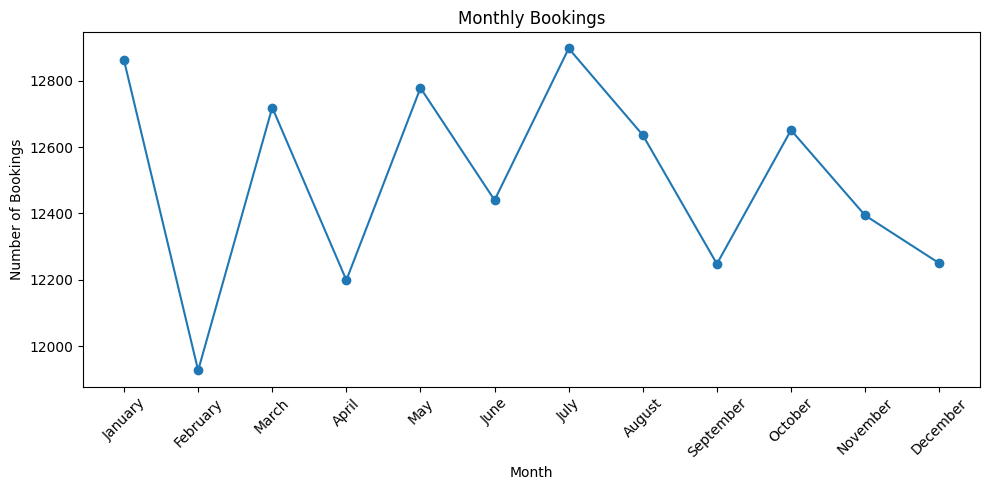

In [57]:
#Monthly bookings
month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

df['Month'] = pd.Categorical(
    df['Month'],
    categories=month_order,
    ordered=True
)
monthly_bookings = (
    df.groupby('Month', observed=True)
      .size()
      .reset_index(name='Bookings')
)

plt.figure(figsize=(10,5))

plt.plot(
    monthly_bookings['Month'],
    monthly_bookings['Bookings'],
    marker='o'
)

plt.title('Monthly Bookings')
plt.xlabel('Month')
plt.ylabel('Number of Bookings')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

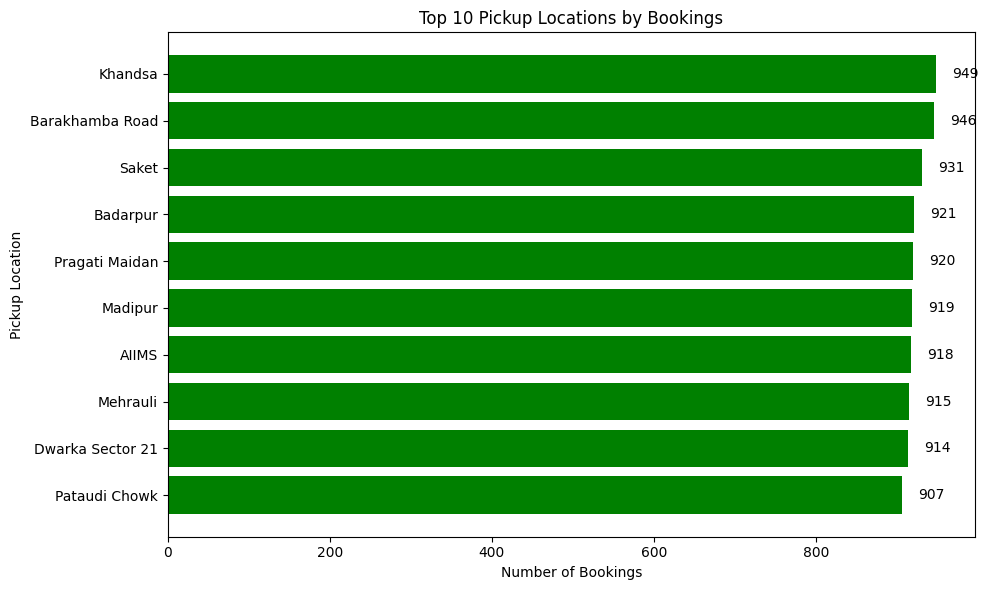

In [58]:
#Bookings by top 10 locations
pickup_bookings = (
    df.groupby('Pickup Location')
      .size()
      .sort_values(ascending=False)
      .head(10)
      .reset_index(name='Bookings')
)

plt.figure(figsize=(10,6))

bars = plt.barh(
    pickup_bookings['Pickup Location'],
    pickup_bookings['Bookings'],
    color='green'
)
# Show values at the end of each bar
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 20,                    # slightly to the right of the bar
        bar.get_y() + bar.get_height()/2,
        f'{int(width):,}',             # 2,362 format
        va='center',
        fontsize=10
    )
plt.title('Top 10 Pickup Locations by Bookings')
plt.xlabel('Number of Bookings')
plt.ylabel('Pickup Location')

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

Rides Cancellation Analysis

In [59]:
df['Booking Status'].value_counts()

Booking Status
Completed                93000
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Incomplete                9000
Name: count, dtype: int64

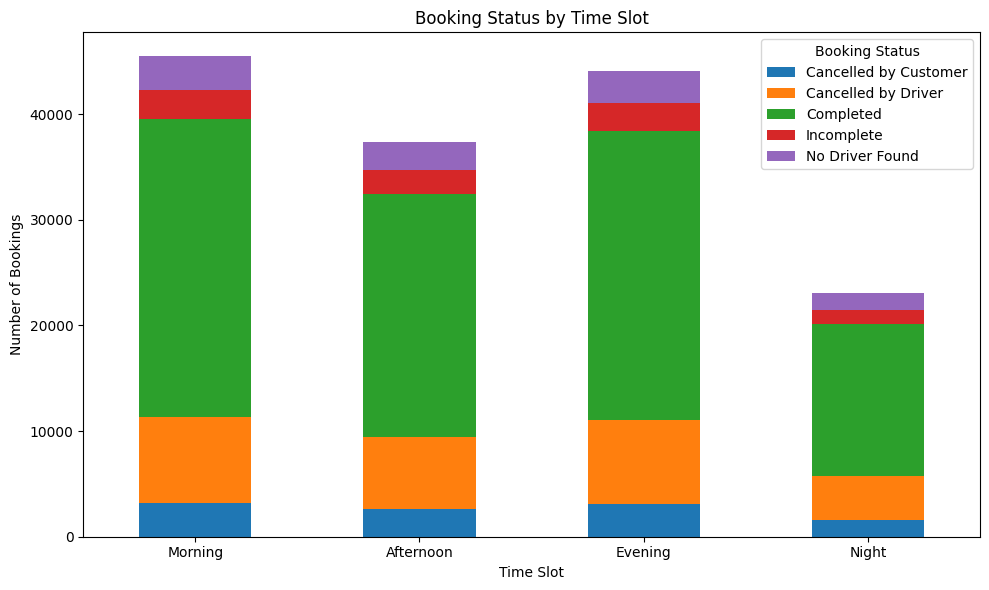

In [60]:
import matplotlib.pyplot as plt

times = ['Morning', 'Afternoon', 'Evening', 'Night']

df['time_category'] = pd.Categorical(
    df['time_category'],
    categories=times,
    ordered=True
)

status_time = pd.crosstab(
    df['time_category'],
    df['Booking Status']
).reindex(times)

status_time.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title('Booking Status by Time Slot')
plt.xlabel('Time Slot')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [61]:
#Month wise booking status
# very minute difference no specific insights obtained
pd.crosstab(df['Month'], df['Booking Status'], normalize='index') * 100


Booking Status,Cancelled by Customer,Cancelled by Driver,Completed,Incomplete,No Driver Found
Month,,,,,
January,6.943473,18.070135,61.822564,6.282560,6.881269
February,7.026075,18.361700,61.775803,5.709734,7.126687
March,7.123202,17.611447,62.536363,5.715858,7.013130
April,6.385769,18.206410,62.562505,5.943110,6.902205
May,7.192049,18.132728,61.864141,6.010330,6.800751
June,7.098071,17.733119,62.355305,5.932476,6.881029
July,7.226487,18.081724,61.456153,6.226254,7.009382
August,6.600190,18.605571,61.570117,5.816714,7.407407
September,7.299151,17.676355,61.577400,6.066297,7.380797


Cancellation or Incomplete Rides analysis

In [62]:
#
df['Cancelled Rides by Customer'].value_counts()
df['Cancelled Rides by Driver'].value_counts()
(df['Booking Status'] == 'Cancelled by Driver').sum()

np.int64(27000)

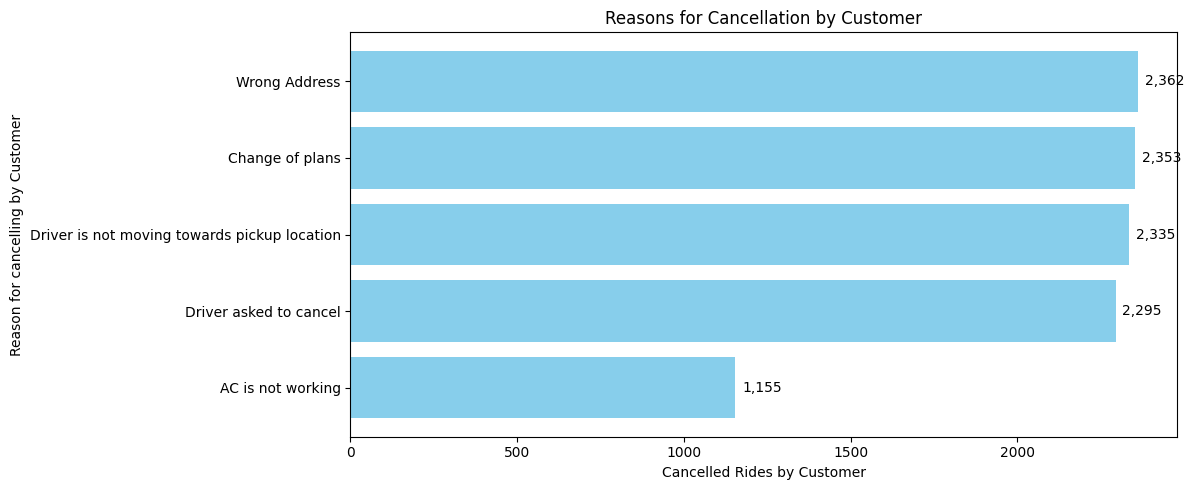

In [63]:
#Customers cancellation reasonS
cust_cancel = df.groupby('Reason for cancelling by Customer')['Cancelled Rides by Customer'].sum().sort_values(ascending = False).reset_index()
plt.figure(figsize=(12,5))

bars = plt.barh(
    cust_cancel['Reason for cancelling by Customer'],
    cust_cancel['Cancelled Rides by Customer'],
    color='skyblue'
)

plt.title('Reasons for Cancellation by Customer')
plt.xlabel('Cancelled Rides by Customer')
plt.ylabel('Reason for cancelling by Customer')

# Show values at the end of each bar
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 20,                    # slightly to the right of the bar
        bar.get_y() + bar.get_height()/2,
        f'{int(width):,}',             # 2,362 format
        va='center',
        fontsize=10
    )
# Highest value at the top
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()


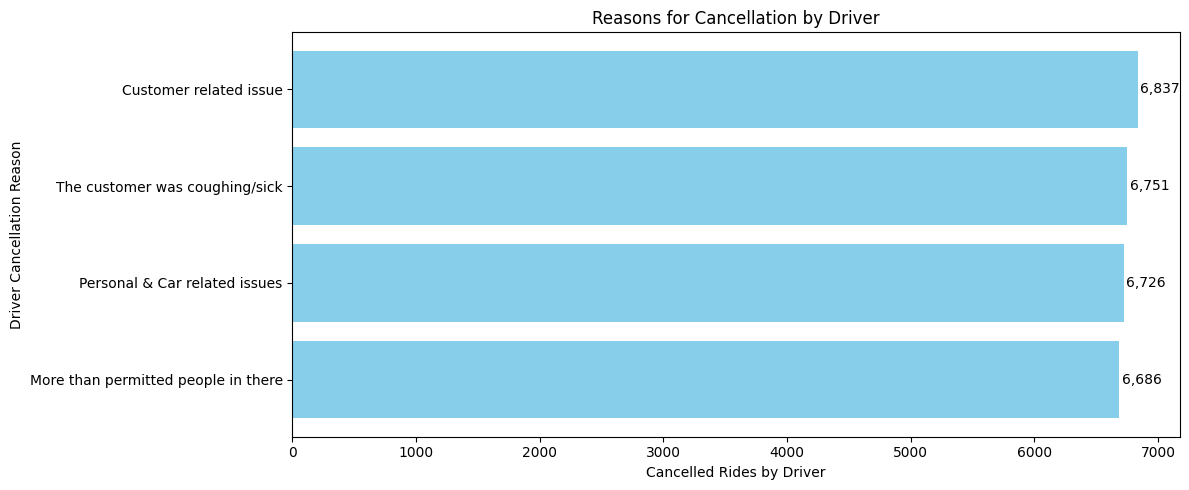

In [64]:
#Drivers cancellation reason
driver_cancel = df.groupby('Driver Cancellation Reason')['Cancelled Rides by Driver'].sum().sort_values(ascending = False).reset_index()
plt.figure(figsize=(12,5))

bars = plt.barh(
    driver_cancel['Driver Cancellation Reason'],
    driver_cancel['Cancelled Rides by Driver'],
    color='skyblue'
)

plt.title('Reasons for Cancellation by Driver')
plt.xlabel('Cancelled Rides by Driver')
plt.ylabel('Driver Cancellation Reason')

# Show values at the end of each bar
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 20,                    # slightly to the right of the bar
        bar.get_y() + bar.get_height()/2,
        f'{int(width):,}',             # 2,362 format
        va='center',
        fontsize=10
    )

# Highest value at the top
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

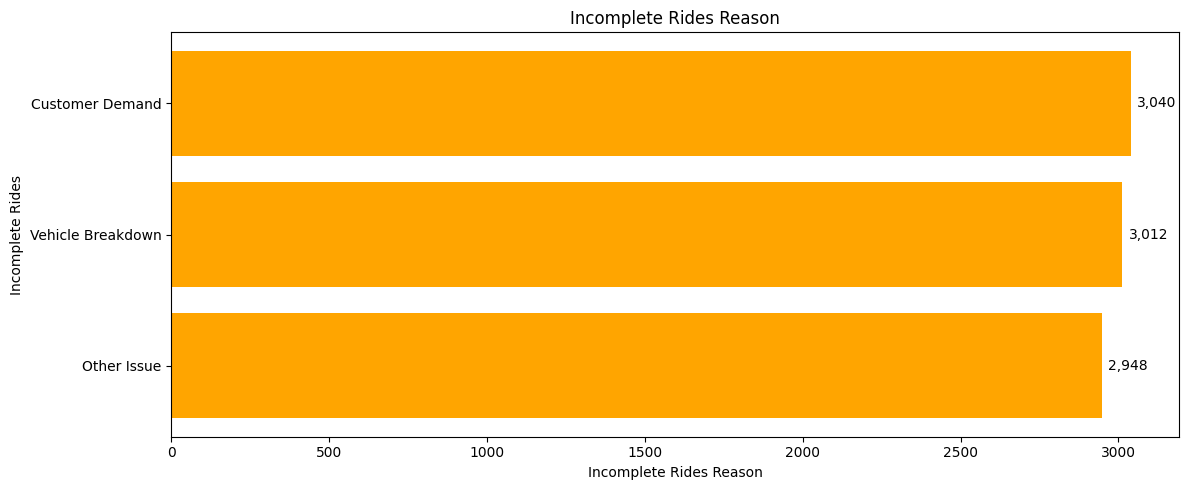

In [65]:
#Incomplete rides 
incomplete_rides = df.groupby('Incomplete Rides Reason')['Incomplete Rides'].sum().sort_values(ascending = False).reset_index()
plt.figure(figsize=(12,5))

bars = plt.barh(
    incomplete_rides['Incomplete Rides Reason'],
    incomplete_rides['Incomplete Rides'],
    color='orange'
)

plt.title('Incomplete Rides Reason')
plt.xlabel('Incomplete Rides Reason')
plt.ylabel('Incomplete Rides')

# Show values at the end of each bar
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 20,                    # slightly to the right of the bar
        bar.get_y() + bar.get_height()/2,
        f'{int(width):,}',             # 2,362 format
        va='center',
        fontsize=10
    )

# Highest value at the top
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [66]:
distance_fare = df[['Ride Distance', 'Booking Value']].dropna()
distance_fare


,Ride Distance,Booking Value
1,5.73,237.0
2,13.58,627.0
3,34.02,416.0
4,48.21,737.0
5,4.85,316.0
...,...,...
149995,40.08,475.0
149996,21.31,1093.0
149997,15.93,852.0
149998,45.54,333.0


In [67]:

correlation = distance_fare['Ride Distance'].corr(distance_fare['Booking Value'])

print(f"Correlation: {correlation:}")

Correlation: 0.005173977125101923


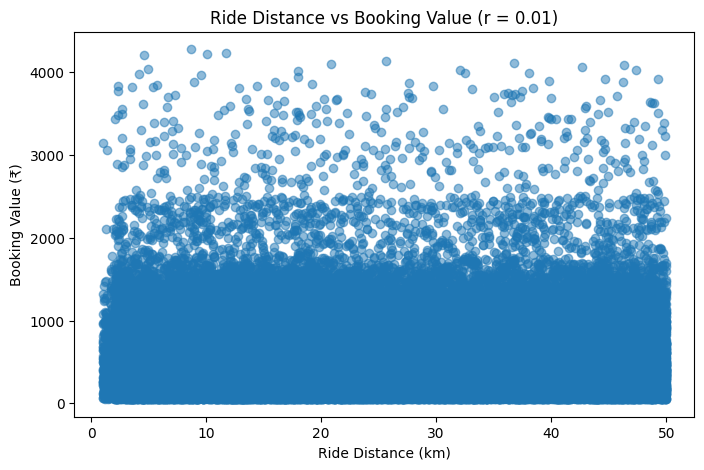

In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    distance_fare['Ride Distance'],
    distance_fare['Booking Value'],
    alpha=0.5
)

plt.title(f'Ride Distance vs Booking Value (r = {correlation:.2f})')
plt.xlabel('Ride Distance (km)')
plt.ylabel('Booking Value (₹)')

plt.show()

In [70]:
#Booking status by vehicle type
df.groupby('Vehicle Type')['Booking Status'].value_counts()

Vehicle Type   Booking Status       
Auto           Completed                23155
               Cancelled by Driver       6643
               No Driver Found           2681
               Cancelled by Customer     2680
               Incomplete                2260
Bike           Completed                14034
               Cancelled by Driver       4077
               Cancelled by Customer     1575
               No Driver Found           1503
               Incomplete                1328
Go Mini        Completed                18549
               Cancelled by Driver       5330
               Cancelled by Customer     2097
               No Driver Found           2015
               Incomplete                1815
Go Sedan       Completed                16676
               Cancelled by Driver       5031
               No Driver Found           1960
               Cancelled by Customer     1832
               Incomplete                1642
Premier Sedan  Completed                112

NameError: name 'st' is not defined

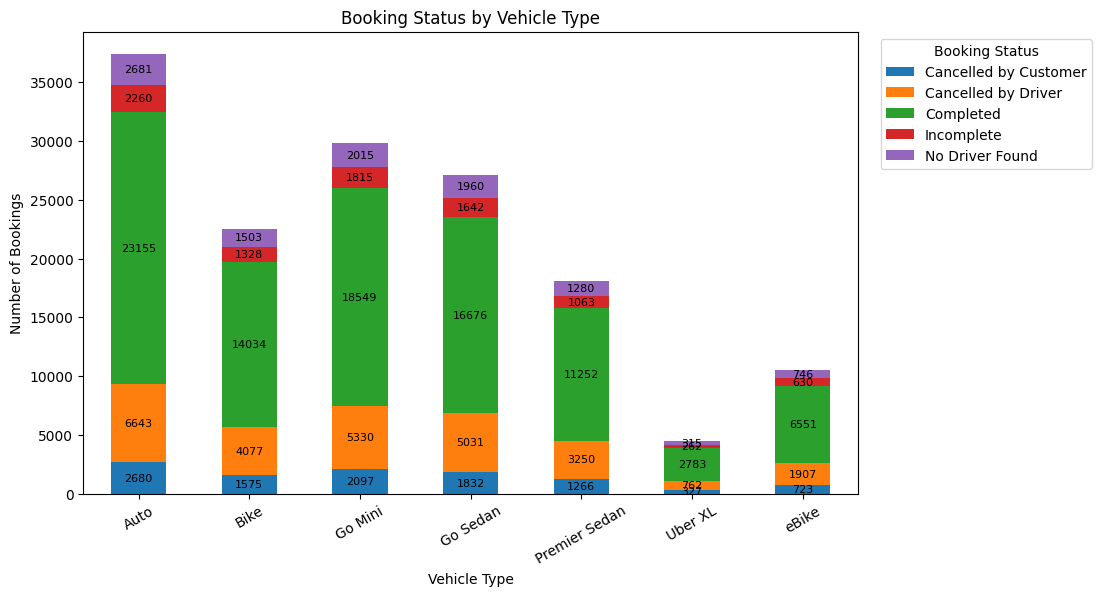

In [72]:
# Booking Status by Vehicle Type

status_vehicle = (
    df.groupby(['Vehicle Type', 'Booking Status'])
      .size()
      .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(10,6))

status_vehicle.plot(
    kind='bar',
    stacked=True,
    ax=ax
)

ax.set_title("Booking Status by Vehicle Type")
ax.set_xlabel("Vehicle Type")
ax.set_ylabel("Number of Bookings")
plt.xticks(rotation=30)
plt.legend(title="Booking Status", bbox_to_anchor=(1.02,1), loc="upper left")

st.pyplot(fig)